# Insurance Claims Analysis & Fraud Risk Detection

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset

In [2]:
df = pd.read_csv('InsuranceData.csv')

# View data

In [3]:
df.head()

,PolicyNumber,CustomerID,Gender,Age,PolicyType,PolicyStartDate,PolicyEndDate,PremiumAmount,CoverageAmount,ClaimNumber,ClaimDate,ClaimAmount,ClaimStatus
0,P1,C1,Female,73,Auto,13-02-2024,13-02-2025,240.64,33175.10,C1,NaN,0.00,Rejected
1,P2,C2,Male,44,Travel,03-03-2024,03-03-2025,1059.73,85046.42,C2,22-06-2024,1493.06,Pending
2,P3,C3,Female,28,Travel,15-06-2024,15-06-2025,1019.59,68525.53,C3,NaN,0.00,Rejected
3,P4,C4,Male,85,Travel,03-06-2024,03-06-2025,549.70,17053.27,C4,25-02-2025,5021.34,Pending
4,P5,C5,Female,57,Travel,13-06-2024,13-06-2025,841.15,55007.27,C5,30-11-2024,1347.46,Pending


# Dataset shape

In [4]:
df.shape

(10004, 13)

# Column names

In [5]:
df.columns

Index(['PolicyNumber', 'CustomerID', 'Gender', 'Age', 'PolicyType',
       'PolicyStartDate', 'PolicyEndDate', 'PremiumAmount', 'CoverageAmount',
       'ClaimNumber', 'ClaimDate', 'ClaimAmount', 'ClaimStatus'],
      dtype='object')

# Dataset information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PolicyNumber     10004 non-null  object 
 1   CustomerID       10004 non-null  object 
 2   Gender           10004 non-null  object 
 3   Age              10004 non-null  int64  
 4   PolicyType       10004 non-null  object 
 5   PolicyStartDate  10004 non-null  object 
 6   PolicyEndDate    10004 non-null  object 
 7   PremiumAmount    10004 non-null  float64
 8   CoverageAmount   10004 non-null  float64
 9   ClaimNumber      10004 non-null  object 
 10  ClaimDate        5649 non-null   object 
 11  ClaimAmount      10004 non-null  float64
 12  ClaimStatus      10004 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 1016.2+ KB


# Dataset information

In [7]:
df.describe()

,Age,PremiumAmount,CoverageAmount,ClaimAmount
count,10004.000000,10004.000000,10004.000000,10004.000000
mean,52.342363,597.458005,60031.137312,1690.554051
std,20.303034,288.289533,28857.815937,1841.771853
min,18.000000,100.020000,10020.270000,0.000000
25%,35.000000,348.730000,35112.092500,0.000000
50%,52.000000,596.570000,60126.795000,1073.280000
75%,70.000000,848.497500,85082.675000,3236.760000
max,87.000000,1099.700000,109992.310000,5499.250000


# Missing values

In [8]:
df.isnull().sum()

PolicyNumber          0
CustomerID            0
Gender                0
Age                   0
PolicyType            0
PolicyStartDate       0
PolicyEndDate         0
PremiumAmount         0
CoverageAmount        0
ClaimNumber           0
ClaimDate          4355
ClaimAmount           0
ClaimStatus           0
dtype: int64

# Duplicate rows

In [9]:
df.duplicated().sum()

np.int64(4)

# Remove duplicates if any

In [10]:
df = df.drop_duplicates()

# Convert dates

In [11]:
df['PolicyStartDate'] = pd.to_datetime(df['PolicyStartDate'], errors='coerce')
df['PolicyEndDate'] = pd.to_datetime(df['PolicyEndDate'], errors='coerce')
df['ClaimDate'] = pd.to_datetime(df['ClaimDate'], errors='coerce')

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_28876\2332006557.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['PolicyStartDate'] = pd.to_datetime(df['PolicyStartDate'], errors='coerce')
C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_28876\2332006557.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['PolicyEndDate'] = pd.to_datetime(df['PolicyEndDate'], errors='coerce')
C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_28876\2332006557.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['ClaimDate'] = pd.to_datetime(df['ClaimDate'], errors='coerce')


# Check missing dates after conversion

In [12]:
df[['PolicyStartDate', 'PolicyEndDate', 'ClaimDate']].isnull().sum()

PolicyStartDate       0
PolicyEndDate         0
ClaimDate          4354
dtype: int64

# Create Age Group

In [13]:
def age_group(age):
    if age <= 25:
        return '18-25'
    elif age <= 35:
        return '26-35'
    elif age <= 45:
        return '36-45'
    elif age <= 55:
        return '46-55'
    else:
        return '55+'

df['Age_Group'] = df['Age'].apply(age_group)


# Days to claim

In [14]:
df['Days_To_Claim'] = (df['ClaimDate'] - df['PolicyStartDate']).dt.days

# Claim timing category


In [15]:
def claim_timing(days):
    if pd.isna(days):
        return 'No Claim Date'
    elif days <= 30:
        return 'Within 30 Days'
    elif days <= 90:
        return '31-90 Days'
    elif days <= 180:
        return '91-180 Days'
    else:
        return '180+ Days'

df['Claim_Timing'] = df['Days_To_Claim'].apply(claim_timing)

# Claim-to-coverage ratio


In [16]:
df['Claim_Coverage_Ratio'] = df['ClaimAmount'] / df['CoverageAmount']

# Claim-to-premium ratio

In [17]:
df['Claim_Premium_Ratio'] = df['ClaimAmount'] / df['PremiumAmount']

# High claim threshold - 95th percentile

In [18]:
high_claim_threshold = df['ClaimAmount'].quantile(0.95)
high_claim_threshold

np.float64(5077.695)

# High risk claim flag

In [19]:
df['High_Risk_Claim'] = np.where(
    df['ClaimAmount'] >= high_claim_threshold,
    1,
    0
)

# Suspicious claim flag

In [20]:
df['Suspicious_Claim'] = np.where(
    (df['Claim_Coverage_Ratio'] >= 0.8) |
    (df['Days_To_Claim'] <= 30),
    1,
    0
)

# Total claims

In [21]:
total_claims = df['ClaimNumber'].nunique()
total_claims

10000

# Total and average claim amount

In [22]:
total_claim_amount = df['ClaimAmount'].sum()
average_claim_amount = df['ClaimAmount'].mean()

total_claim_amount, average_claim_amount

(np.float64(16904295.27), np.float64(1690.429527))

# Claim status distribution

In [23]:
claim_status = df['ClaimStatus'].value_counts()
claim_status

ClaimStatus
Rejected    4354
Settled     3386
Pending     2260
Name: count, dtype: int64

# Claim status percentage

In [24]:
claim_status_pct = df['ClaimStatus'].value_counts(normalize=True) * 100
claim_status_pct.round(2)

ClaimStatus
Rejected    43.54
Settled     33.86
Pending     22.60
Name: proportion, dtype: float64

# Visualization: Claim Status Distribution

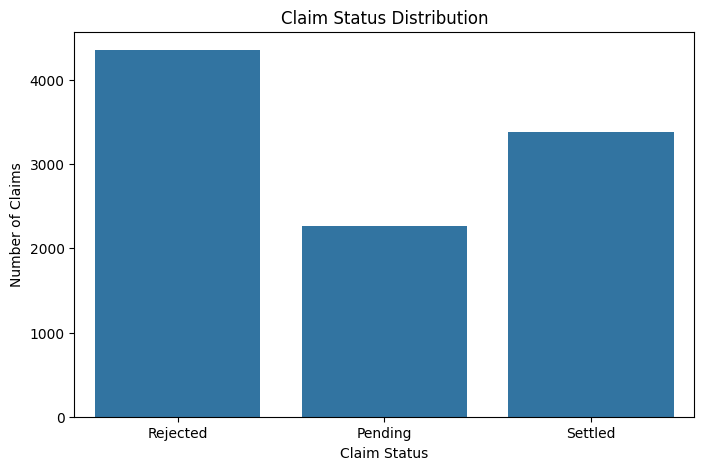

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='ClaimStatus', data=df)
plt.title('Claim Status Distribution')
plt.xlabel('Claim Status')
plt.ylabel('Number of Claims')
plt.show()

# Claim amount by policy type

In [26]:
policy_claim_amount = df.groupby('PolicyType')['ClaimAmount'].sum().sort_values(ascending=False)
policy_claim_amount

PolicyType
Travel    7088861.88
Health    3432319.02
Auto      2724347.12
Life      2063004.60
Home      1595762.65
Name: ClaimAmount, dtype: float64

# Visualization: Claim Amount by Policy Type

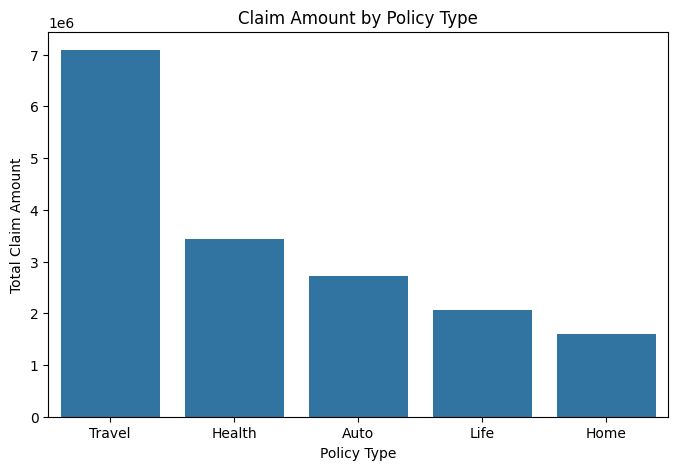

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(x=policy_claim_amount.index, y=policy_claim_amount.values)
plt.title('Claim Amount by Policy Type')
plt.xlabel('Policy Type')
plt.ylabel('Total Claim Amount')
plt.show()

# Average premium by policy type

In [28]:
df.groupby('PolicyType')['PremiumAmount'].mean().sort_values(ascending=False)

PolicyType
Auto      602.022020
Health    599.863520
Travel    597.264374
Home      596.478835
Life      588.794912
Name: PremiumAmount, dtype: float64

# Average coverage by policy type

In [29]:
df.groupby('PolicyType')['CoverageAmount'].mean().sort_values(ascending=False)

PolicyType
Travel    60467.675221
Home      60270.076782
Health    60050.910175
Life      59377.839840
Auto      59243.231129
Name: CoverageAmount, dtype: float64

# Claims by gender

In [30]:
df.groupby('Gender')['ClaimNumber'].count()

Gender
Female    5000
Male      5000
Name: ClaimNumber, dtype: int64

# Visualization: Claims by Gender

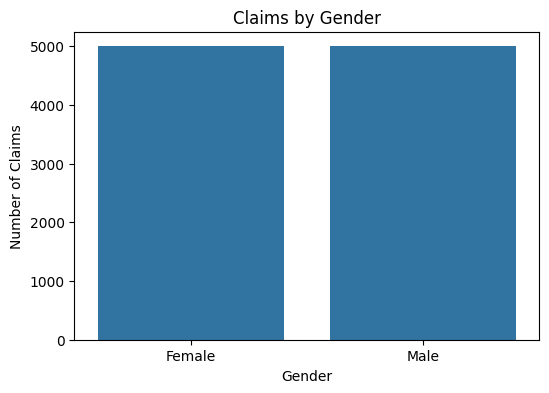

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Claims by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Claims')
plt.show()

# Claims by age group

In [32]:
age_claims = df.groupby('Age_Group')['ClaimNumber'].count()
age_claims

Age_Group
18-25    1161
26-35    1437
36-45    1461
46-55    1429
55+      4512
Name: ClaimNumber, dtype: int64

# Sort age groups

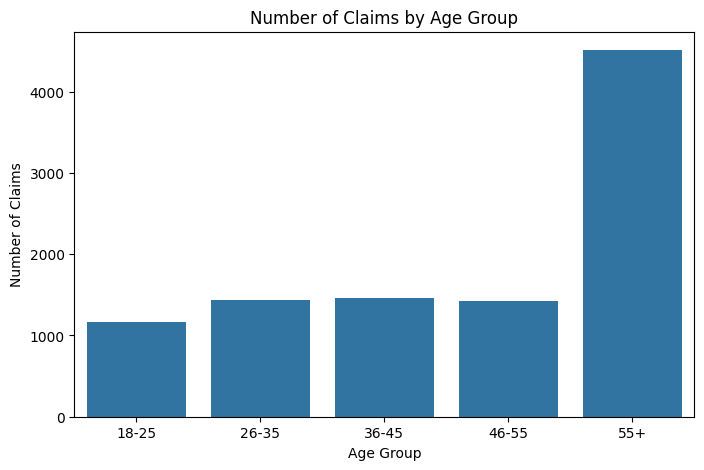

In [33]:
age_order = ['18-25', '26-35', '36-45', '46-55', '55+']

plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group', data=df, order=age_order)
plt.title('Number of Claims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Claims')
plt.show()

# Claim amount by age group

In [34]:
age_claim_amount = df.groupby('Age_Group')['ClaimAmount'].sum().reindex(age_order)
age_claim_amount

Age_Group
18-25    1934904.97
26-35    2303455.52
36-45    2572914.18
46-55    2438620.52
55+      7654400.08
Name: ClaimAmount, dtype: float64

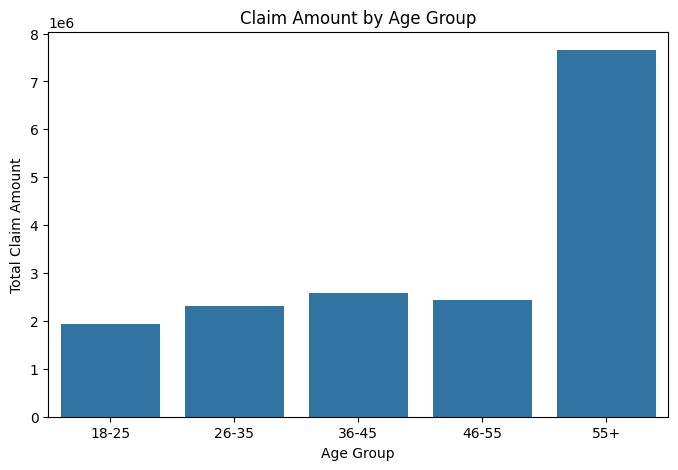

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x=age_claim_amount.index, y=age_claim_amount.values)
plt.title('Claim Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Claim Amount')
plt.show()

# Claim status by policy type

In [36]:
pd.crosstab(df['PolicyType'], df['ClaimStatus'])

ClaimStatus,Pending,Rejected,Settled
PolicyType,,,
Auto,357,673,564
Health,458,867,675
Home,212,468,333
Life,296,566,386
Travel,937,1780,1428


# Visualization: Claim Status by Policy Type

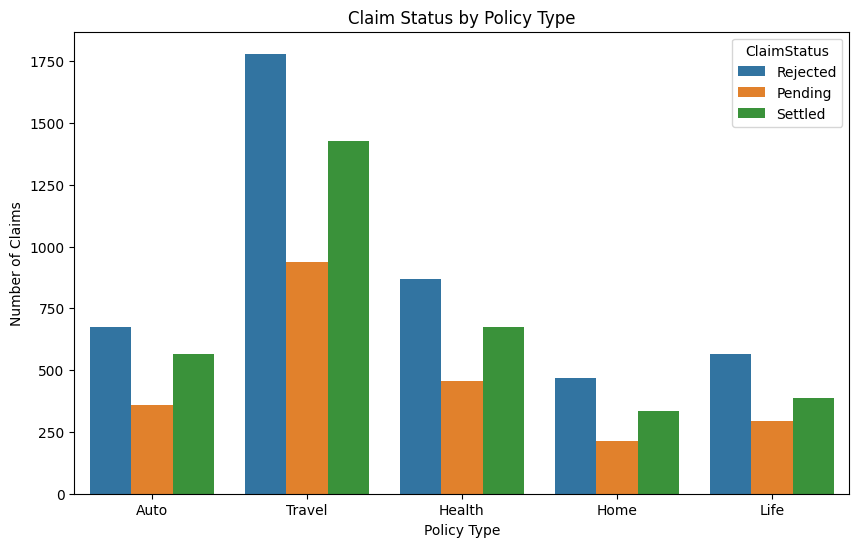

In [37]:
plt.figure(figsize=(10,6))
sns.countplot(x='PolicyType', hue='ClaimStatus', data=df)
plt.title('Claim Status by Policy Type')
plt.xlabel('Policy Type')
plt.ylabel('Number of Claims')
plt.show()

# Top 20 highest claims

In [38]:
top_20_claims = df.sort_values(by='ClaimAmount', ascending=False).head(20)
top_20_claims[
    ['ClaimNumber', 'CustomerID', 'PolicyType', 'PremiumAmount',
     'CoverageAmount', 'ClaimAmount', 'ClaimStatus']
]

,ClaimNumber,CustomerID,PolicyType,PremiumAmount,CoverageAmount,ClaimAmount,ClaimStatus
9202,C9203,C9203,Auto,652.38,26959.13,5499.25,Pending
4339,C4340,C4340,Auto,213.84,96575.23,5498.58,Settled
3059,C3060,C3060,Health,976.57,75165.44,5496.36,Pending
4507,C4508,C4508,Home,918.39,96188.63,5495.65,Pending
8726,C8727,C8727,Travel,913.64,81245.52,5495.45,Pending
2656,C2657,C2657,Home,854.23,15687.58,5494.70,Settled
7305,C7306,C7306,Auto,569.99,80755.07,5494.64,Settled
3533,C3534,C3534,Auto,320.63,73756.96,5494.45,Pending
4317,C4318,C4318,Health,256.36,22871.19,5493.75,Pending
7299,C7300,C7300,Auto,883.56,70173.40,5491.93,Pending


# Visualization: Top 20 Highest Claims

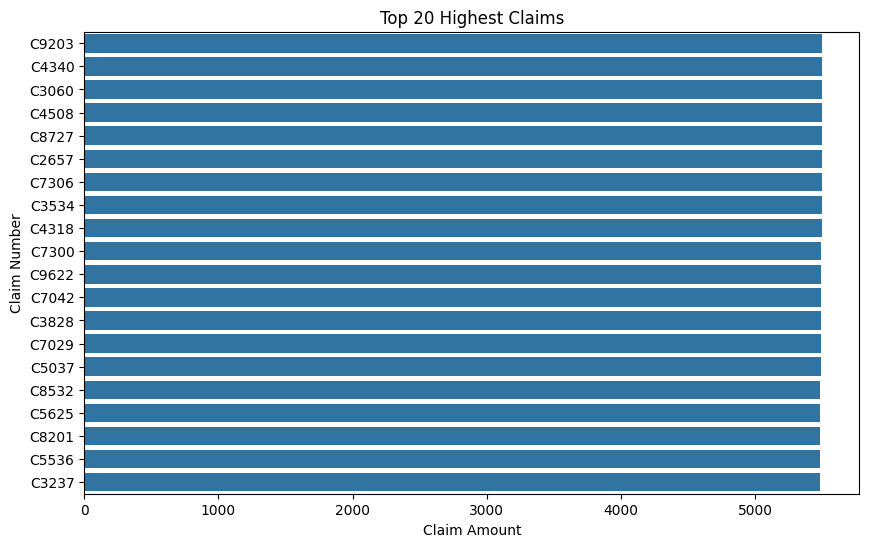

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='ClaimAmount',
    y='ClaimNumber',
    data=top_20_claims
)
plt.title('Top 20 Highest Claims')
plt.xlabel('Claim Amount')
plt.ylabel('Claim Number')
plt.show()

# Average claim-to-coverage ratio by policy type

In [40]:
ratio_by_policy = (
    df[df['ClaimAmount'] > 0]
    .groupby('PolicyType')['Claim_Coverage_Ratio']
    .mean()
    .sort_values(ascending=False)
)

ratio_by_policy

PolicyType
Auto      0.076171
Life      0.074073
Health    0.072646
Travel    0.070863
Home      0.065930
Name: Claim_Coverage_Ratio, dtype: float64

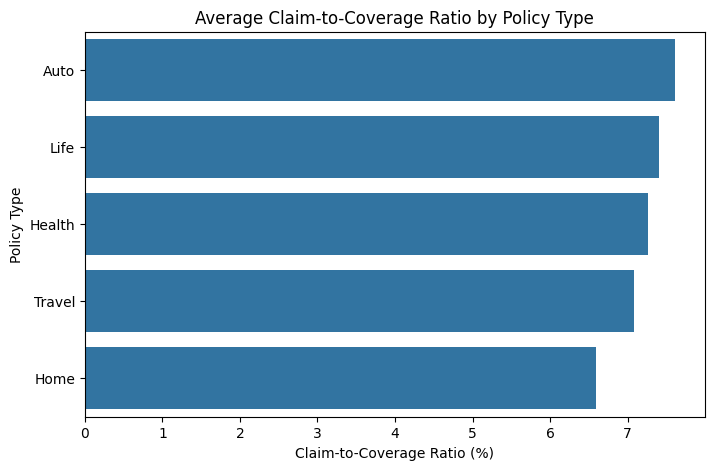

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=ratio_by_policy.values * 100,
    y=ratio_by_policy.index
)
plt.title('Average Claim-to-Coverage Ratio by Policy Type')
plt.xlabel('Claim-to-Coverage Ratio (%)')
plt.ylabel('Policy Type')
plt.show()

# Claim timing distribution

In [42]:
claim_timing_counts = df['Claim_Timing'].value_counts()
claim_timing_counts

Claim_Timing
No Claim Date     4354
180+ Days         2855
91-180 Days       1397
31-90 Days         939
Within 30 Days     455
Name: count, dtype: int64

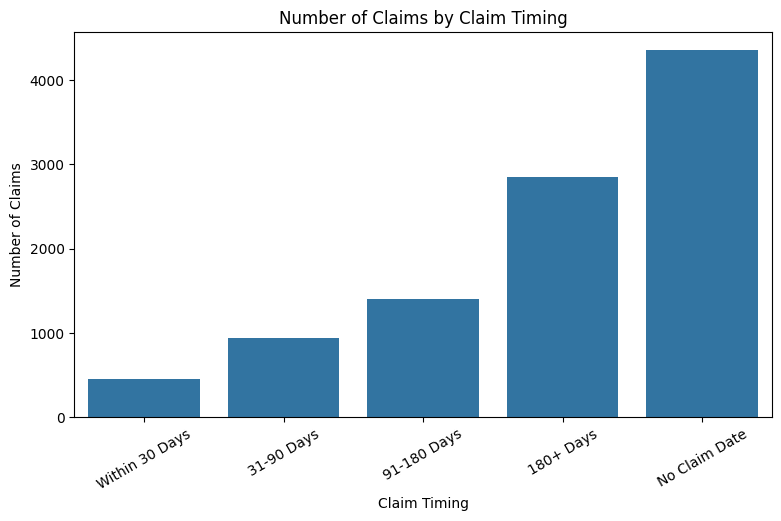

In [43]:
timing_order = ['Within 30 Days', '31-90 Days', '91-180 Days', '180+ Days', 'No Claim Date']

plt.figure(figsize=(9,5))
sns.countplot(
    x='Claim_Timing',
    data=df,
    order=timing_order
)
plt.title('Number of Claims by Claim Timing')
plt.xlabel('Claim Timing')
plt.ylabel('Number of Claims')
plt.xticks(rotation=30)
plt.show()

# Premium Amount vs Claim Amount

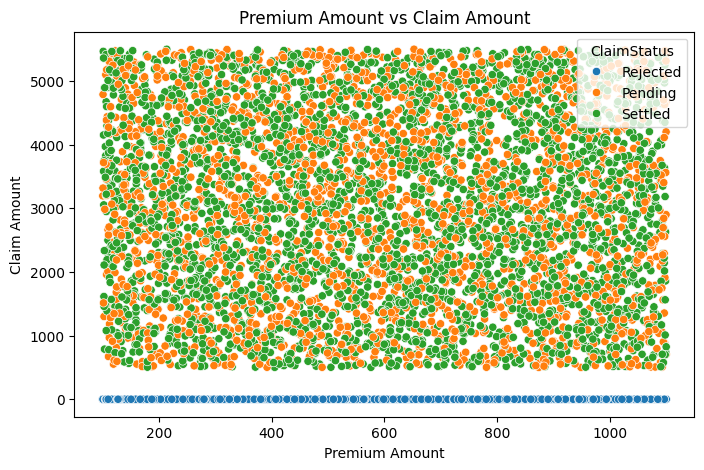

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='PremiumAmount',
    y='ClaimAmount',
    hue='ClaimStatus',
    data=df
)
plt.title('Premium Amount vs Claim Amount')
plt.xlabel('Premium Amount')
plt.ylabel('Claim Amount')
plt.show()

# Suspicious claims count

In [45]:
df['Suspicious_Claim'].sum()

np.int64(455)

# High risk claims count

In [46]:
df['High_Risk_Claim'].sum()

np.int64(500)

# Suspicious claims table

In [47]:
suspicious_claims = df[df['Suspicious_Claim'] == 1]

suspicious_claims[
    ['ClaimNumber', 'CustomerID', 'PolicyType', 'PremiumAmount',
     'CoverageAmount', 'ClaimAmount', 'ClaimStatus',
     'Days_To_Claim', 'Claim_Coverage_Ratio']
].head(10)

,ClaimNumber,CustomerID,PolicyType,PremiumAmount,CoverageAmount,ClaimAmount,ClaimStatus,Days_To_Claim,Claim_Coverage_Ratio
45,C46,C46,Health,433.83,86926.39,5103.87,Settled,25.0,0.058715
54,C55,C55,Auto,898.81,27298.93,4975.59,Settled,19.0,0.182263
212,C213,C213,Health,736.35,12002.74,3704.31,Settled,10.0,0.308622
235,C236,C236,Health,105.68,72813.44,5098.30,Pending,9.0,0.070019
251,C252,C252,Travel,294.30,31357.61,2017.12,Settled,29.0,0.064326
254,C255,C255,Travel,373.20,18994.29,5455.93,Settled,5.0,0.287241
262,C263,C263,Auto,169.13,51104.05,3522.09,Pending,10.0,0.068920
278,C279,C279,Home,162.62,43916.79,2480.60,Settled,29.0,0.056484
289,C290,C290,Travel,1015.08,80501.40,520.05,Settled,17.0,0.006460
324,C325,C325,Health,237.26,17042.38,4581.80,Pending,15.0,0.268847


# High risk claims table

In [48]:
high_risk_claims = df[df['High_Risk_Claim'] == 1]

high_risk_claims[
    ['ClaimNumber', 'CustomerID', 'PolicyType', 'PremiumAmount',
     'CoverageAmount', 'ClaimAmount', 'ClaimStatus',
     'Days_To_Claim', 'Claim_Coverage_Ratio']
].head(10)

,ClaimNumber,CustomerID,PolicyType,PremiumAmount,CoverageAmount,ClaimAmount,ClaimStatus,Days_To_Claim,Claim_Coverage_Ratio
6,C7,C7,Travel,573.25,91251.70,5431.79,Pending,190.0,0.059525
9,C10,C10,Travel,607.42,88203.38,5118.08,Pending,77.0,0.058026
35,C36,C36,Auto,455.01,45366.22,5406.07,Settled,254.0,0.119165
45,C46,C46,Health,433.83,86926.39,5103.87,Settled,25.0,0.058715
47,C48,C48,Auto,257.92,34307.65,5119.79,Pending,252.0,0.149232
48,C49,C49,Auto,480.50,73381.08,5339.42,Settled,319.0,0.072763
73,C74,C74,Travel,984.18,68195.68,5336.41,Settled,174.0,0.078251
75,C76,C76,Auto,1093.73,87697.15,5311.26,Settled,232.0,0.060564
83,C84,C84,Home,1033.72,48521.83,5177.51,Pending,258.0,0.106705
90,C91,C91,Travel,323.08,41790.05,5435.99,Settled,211.0,0.130079


# Correlation analysis

In [49]:
numeric_cols = [
    'Age',
    'PremiumAmount',
    'CoverageAmount',
    'ClaimAmount',
    'Days_To_Claim',
    'Claim_Coverage_Ratio',
    'Claim_Premium_Ratio'
]

corr = df[numeric_cols].corr()
corr

,Age,PremiumAmount,CoverageAmount,ClaimAmount,Days_To_Claim,Claim_Coverage_Ratio,Claim_Premium_Ratio
Age,1.000000,0.018447,0.018707,0.008304,0.000074,-0.004046,-0.007883
PremiumAmount,0.018447,1.000000,0.003274,-0.009476,-0.000991,0.000307,-0.410904
CoverageAmount,0.018707,0.003274,1.000000,0.006828,-0.030451,-0.402638,0.009071
ClaimAmount,0.008304,-0.009476,0.006828,1.000000,-0.018823,0.684503,0.692478
Days_To_Claim,0.000074,-0.000991,-0.030451,-0.018823,1.000000,0.004493,-0.002631
Claim_Coverage_Ratio,-0.004046,0.000307,-0.402638,0.684503,0.004493,1.000000,0.462282
Claim_Premium_Ratio,-0.007883,-0.410904,0.009071,0.692478,-0.002631,0.462282,1.000000


# Correlation heatmap

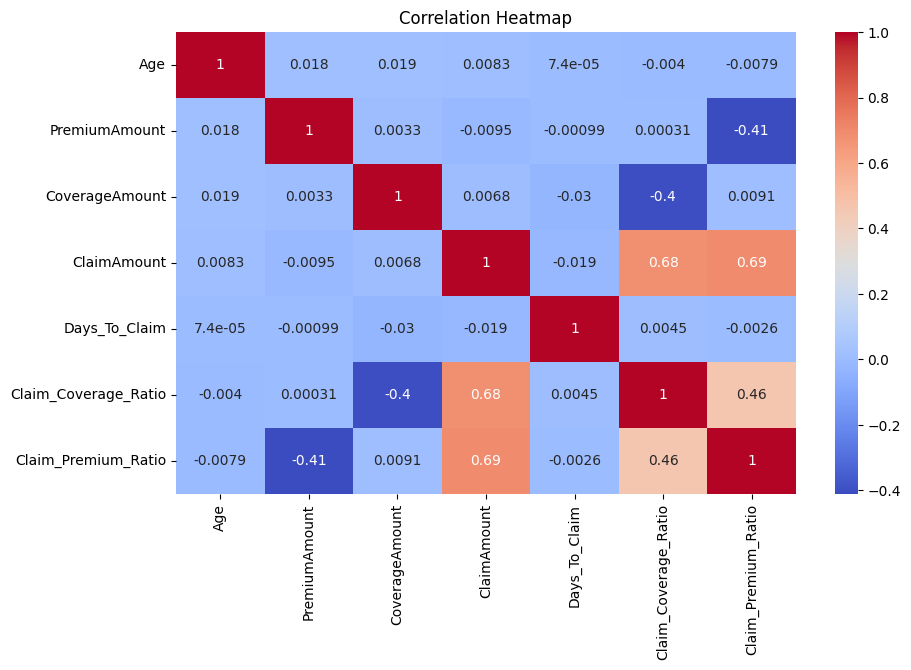

In [50]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Final dataset export after feature engineering

In [51]:
df.to_csv("Insurance_Claims_Cleaned.csv", index=False)